Comenzamos conectandonos al Drive

In [ ]:
# 1. Conectar con Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Instalar las librerías de Deep Learning
!pip install -q transformers datasets evaluate accelerate
print("Entorno configurado correctamente.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Entorno configurado correctamente.


Cargamos el Dataset de Entrenamiento

In [ ]:
import pandas as pd
import numpy as np

# Definir la ruta de tus datos
ruta_carpeta = '/content/drive/MyDrive/TFM_Personalidad'

# Cargar el archivo de entrenamiento
df_train = pd.read_csv(f'{ruta_carpeta}/train_personalidad.csv')

# Empaquetar los 5 rasgos en una única columna de etiquetas (labels)
rasgos = ['Extroversion', 'Neuroticism', 'Agreeableness', 'Conscientiousness', 'Openness']
df_train['labels'] = df_train[rasgos].values.astype(float).tolist()

print(f"Total de textos para entrenar: {len(df_train)}")
print("Ejemplo de vector de etiquetas preparado para la GPU:", df_train['labels'].iloc[0])

Total de textos para entrenar: 1967
Ejemplo de vector de etiquetas preparado para la GPU: [1.0, 0.0, 1.0, 0.0, 0.0]


Cargaremos el tokenizador de nuestro modelo "David" (distilbert-base-uncased) para transformar el texto en matrices numéricas

In [ ]:
from datasets import Dataset
from transformers import AutoTokenizer

# 1. Convertir el DataFrame al formato ultrarrápido de Hugging Face
dataset_train = Dataset.from_pandas(df_train[['TEXT', 'labels']])

# 2. Cargar el tokenizador oficial
nombre_modelo_base = "distilbert-base-uncased"
tokenizador = AutoTokenizer.from_pretrained(nombre_modelo_base)

# 3. Definir la regla de tokenización (truncamos a 512 tokens, máximo estándar)
def tokenizar_textos(ejemplos):
    return tokenizador(ejemplos["TEXT"], padding="max_length", truncation=True, max_length=512)

# 4. Traducir masivamente todo el dataset
dataset_tokenizado = dataset_train.map(tokenizar_textos, batched=True)

print("\n¡Traducción completada! Los textos ya son tensores numéricos.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/1967 [00:00<?, ? examples/s]


¡Traducción completada! Los textos ya son tensores numéricos.


Preparar la Validación y el Modelo Base

In [ ]:
from transformers import AutoModelForSequenceClassification

# 1. Separamos un 10% para validación interna (1770 para estudiar, 197 para autoevaluarse)
dataset_final = dataset_tokenizado.train_test_split(test_size=0.1, seed=42)

# 2. Descargamos la estructura del cerebro neuronal
modelo = AutoModelForSequenceClassification.from_pretrained(
    nombre_modelo_base,
    num_labels=5, # Las 5 dimensiones del Big Five
    problem_type="multi_label_classification"
)

print("¡Red neuronal cargada en memoria y lista para aprender!")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


¡Red neuronal cargada en memoria y lista para aprender!


Definir la métrica de corrección matemática

In [ ]:
from sklearn.metrics import accuracy_score
import torch

def calcular_metricas(eval_pred):
    predicciones_crudas, etiquetas_reales = eval_pred

    # Convertimos los números crudos en un tensor matemático
    tensor_predicciones = torch.tensor(predicciones_crudas)

    # 1. Aplicamos la Sigmoide para obtener probabilidades (0.0 a 1.0)
    probabilidades = torch.sigmoid(tensor_predicciones)

    # 2. Aplicamos el umbral del 50%: > 0.5 es 1, <= 0.5 es 0
    predicciones_binarias = (probabilidades > 0.5).int().numpy()

    # 3. Comparamos con las etiquetas reales de nuestro dataset
    accuracy = accuracy_score(etiquetas_reales, predicciones_binarias)

    return {"accuracy_general": accuracy}

Configurar hiperparámetros y encender los motores

In [ ]:
from transformers import TrainingArguments, Trainer

argumentos_entrenamiento = TrainingArguments(
    output_dir="./modelo_personalidad_tfm",
    eval_strategy="epoch",            # Nombre del parámetro actualizado
    save_strategy="epoch",            # Guardar una copia en cada época
    learning_rate=2e-5,               # Velocidad de aprendizaje lenta y segura
    per_device_train_batch_size=16,   # Textos que lee a la vez
    per_device_eval_batch_size=16,
    num_train_epochs=4,               # Dar 4 vueltas completas a los apuntes
    weight_decay=0.01,                # Regularización para evitar el Overfitting
    load_best_model_at_end=True,      # Al acabar, quedarse con la versión que sacó mejor nota
)

entrenador = Trainer(
    model=modelo,
    args=argumentos_entrenamiento,
    train_dataset=dataset_final["train"],
    eval_dataset=dataset_final["test"],
    compute_metrics=calcular_metricas,
)

print("Arrancando el Fine-Tuning en la GPU")
entrenador.train()

Arrancando el Fine-Tuning en la GPU


Epoch,Training Loss,Validation Loss,Accuracy General
1,No log,0.689001,0.035533
2,No log,0.677866,0.055838
3,No log,0.674535,0.081218
4,No log,0.675164,0.076142


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=444, training_loss=0.6742636190878378, metrics={'train_runtime': 388.169, 'train_samples_per_second': 18.239, 'train_steps_per_second': 1.144, 'total_flos': 937919359180800.0, 'train_loss': 0.6742636190878378, 'epoch': 4.0})

Cargar el Test Set (Los 500 textos intocables)

In [ ]:
# Cargar el test set aislado en la Fase 1
df_test = pd.read_csv(f'{ruta_carpeta}/test_personalidad.csv')

# Formatear las etiquetas reales igual que hicimos en train
df_test['labels'] = df_test[rasgos].values.astype(float).tolist()

# Convertirlo al formato de Hugging Face y tokenizarlo
dataset_test = Dataset.from_pandas(df_test[['TEXT', 'labels']])
dataset_test_tokenizado = dataset_test.map(tokenizar_textos, batched=True)

print(f"Examen final preparado con {len(df_test)} textos.")

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Examen final preparado con 500 textos.


Predecir el Test Set con tu modelo entrenado

In [ ]:
import torch

print("Evaluando el Test Set de 500 textos. Espera unos segundos...")

# Usamos el entrenador para generar predicciones crudas
predicciones_raw = entrenador.predict(dataset_test_tokenizado)

# Extraemos los números y aplicamos la misma lógica matemática (Sigmoide + Umbral 0.5)
tensor_preds = torch.tensor(predicciones_raw.predictions)
probabilidades = torch.sigmoid(tensor_preds)
predicciones_binarias = (probabilidades > 0.5).int().numpy()

print("¡Predicciones generadas!")

Evaluando el Test Set de 500 textos. Espera unos segundos...


¡Predicciones generadas!


Extraer la Precisión Rasgo a Rasgo (El Benchmark Justo)

In [ ]:
resultados_propios = []

for i, rasgo in enumerate(rasgos):
    # Extraemos la columna 'i' de nuestras predicciones (0 o 1)
    preds_rasgo = predicciones_binarias[:, i]

    # Extraemos las etiquetas reales para ese rasgo
    reales_rasgo = df_test[rasgo].values

    # Calculamos la precisión clásica
    aciertos = (preds_rasgo == reales_rasgo).mean() * 100

    resultados_propios.append({
        'Modelo': 'Mi DistilBERT',
        'Rasgo': rasgo,
        'Accuracy (%)': round(aciertos, 2)
    })

df_resultados_propios = pd.DataFrame(resultados_propios)
print("\n--- RENDIMIENTO REAL DE TU MODELO ---")
print(df_resultados_propios)


--- RENDIMIENTO REAL DE TU MODELO ---
          Modelo              Rasgo  Accuracy (%)
0  Mi DistilBERT       Extroversion          51.4
1  Mi DistilBERT        Neuroticism          55.0
2  Mi DistilBERT      Agreeableness          56.2
3  Mi DistilBERT  Conscientiousness          57.2
4  Mi DistilBERT           Openness          62.0


Cargar el "Cerebro" de RoBERTa

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

nombre_modelo_mejorado = "roberta-base"

# 1. Cargamos el nuevo tokenizador
tokenizador_roberta = AutoTokenizer.from_pretrained(nombre_modelo_mejorado)

# 2. Cargamos la nueva red neuronal (con las 5 neuronas de salida)
modelo_roberta = AutoModelForSequenceClassification.from_pretrained(
    nombre_modelo_mejorado,
    num_labels=5,
    problem_type="multi_label_classification"
)

print("¡Arquitectura RoBERTa cargada! Este modelo es más pesado y capaz.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


¡Arquitectura RoBERTa cargada! Este modelo es más pesado y capaz.


Re-tokenizar el Dataset

In [ ]:
# Función de tokenización con el nuevo tokenizador
def tokenizar_roberta(ejemplos):
    return tokenizador_roberta(ejemplos["TEXT"], padding="max_length", truncation=True, max_length=512)

# Aplicamos la traducción a nuestro dataset original (el que separamos en train/test en el Paso 4)
dataset_roberta_tokenizado = dataset_final.map(tokenizar_roberta, batched=True)

print("Textos re-traducidos al lenguaje de RoBERTa.")

Map:   0%|          | 0/1770 [00:00<?, ? examples/s]

Map:   0%|          | 0/197 [00:00<?, ? examples/s]

Textos re-traducidos al lenguaje de RoBERTa.


Entrenamiento Avanzado con Early Stopping

In [ ]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

argumentos_mejorados = TrainingArguments(
    output_dir="./modelo_roberta_tfm",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=8,               # Le damos el doble de tiempo para aprender
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",# La métrica que mirará para saber si mejora
    greater_is_better=False           # Como es "pérdida" (loss), queremos que sea menor
)

entrenador_roberta = Trainer(
    model=modelo_roberta,
    args=argumentos_mejorados,
    train_dataset=dataset_roberta_tokenizado["train"],
    eval_dataset=dataset_roberta_tokenizado["test"],
    compute_metrics=calcular_metricas, # Usamos la misma función matemática del Paso 5
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)] # ¡El seguro anti-memorización!
)

print("¡Iniciando Fine-Tuning con RoBERTa y Early Stopping!")
entrenador_roberta.train()

¡Iniciando Fine-Tuning con RoBERTa y Early Stopping!


Epoch,Training Loss,Validation Loss,Accuracy General
1,No log,0.690859,0.045685
2,No log,0.691645,0.071066
3,No log,0.673819,0.065990
4,No log,0.690463,0.071066
5,0.662783,0.712996,0.050761


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=555, training_loss=0.6564634443403364, metrics={'train_runtime': 1034.3924, 'train_samples_per_second': 13.689, 'train_steps_per_second': 0.858, 'total_flos': 2328595560806400.0, 'train_loss': 0.6564634443403364, 'epoch': 5.0})

Preparar el examen final para RoBERTa

In [ ]:
# Cargar el test set
df_test = pd.read_csv(f'{ruta_carpeta}/test_personalidad.csv')
df_test['labels'] = df_test[rasgos].values.astype(float).tolist()

# Convertir y tokenizar
dataset_test = Dataset.from_pandas(df_test[['TEXT', 'labels']])
dataset_test_roberta = dataset_test.map(tokenizar_roberta, batched=True)

print("¡Examen final traducido al lenguaje RoBERTa!")

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

¡Examen final traducido al lenguaje RoBERTa!


Generar las predicciones y extraer la precisión real

In [ ]:
import torch

print("Evaluando el Test Set con RoBERTa. Espera unos segundos...")

# Generar predicciones matemáticas
preds_raw_roberta = entrenador_roberta.predict(dataset_test_roberta)

# Aplicar la función Sigmoide y el umbral
tensor_preds_rob = torch.tensor(preds_raw_roberta.predictions)
probs_rob = torch.sigmoid(tensor_preds_rob)
preds_bin_rob = (probs_rob > 0.5).int().numpy()

# Calcular el Accuracy rasgo a rasgo
resultados_roberta = []
for i, rasgo in enumerate(rasgos):
    aciertos = (preds_bin_rob[:, i] == df_test[rasgo].values).mean() * 100
    resultados_roberta.append({
        'Modelo': 'Mi RoBERTa',
        'Rasgo': rasgo,
        'Accuracy (%)': round(aciertos, 2)
    })

df_res_roberta = pd.DataFrame(resultados_roberta)
print("\n--- RENDIMIENTO DE ROBERTA ---")
print(df_res_roberta)

Evaluando el Test Set con RoBERTa. Espera unos segundos...



--- RENDIMIENTO DE ROBERTA ---
       Modelo              Rasgo  Accuracy (%)
0  Mi RoBERTa       Extroversion          51.2
1  Mi RoBERTa        Neuroticism          55.0
2  Mi RoBERTa      Agreeableness          57.4
3  Mi RoBERTa  Conscientiousness          55.2
4  Mi RoBERTa           Openness          61.8


Guardar esta tabla de resultados para poder compararla

In [ ]:
import shutil

# Guardamos los resultados de RoBERTa en un CSV
df_res_roberta.to_csv(f'{ruta_carpeta}/Resultados_RoBERTa.csv', index=False)

# Sobrescribimos la carpeta del modelo en Drive con esta versión superior
try:
    shutil.copytree('./modelo_roberta_tfm', f'{ruta_carpeta}/Mi_Modelo_Entrenado_Final', dirs_exist_ok=True)
    print("¡Resultados y modelo RoBERTa guardados en Drive de forma segura!")
except Exception as e:
    print("El modelo ya estaba guardado o hubo un aviso menor. Seguimos adelante.")

¡Resultados y modelo RoBERTa guardados en Drive de forma segura!


Cargar y unificar todos los datos desde tu Drive

¡Gráfica exportada correctamente como 'grafica_final_tfm.png' en tu Google Drive!


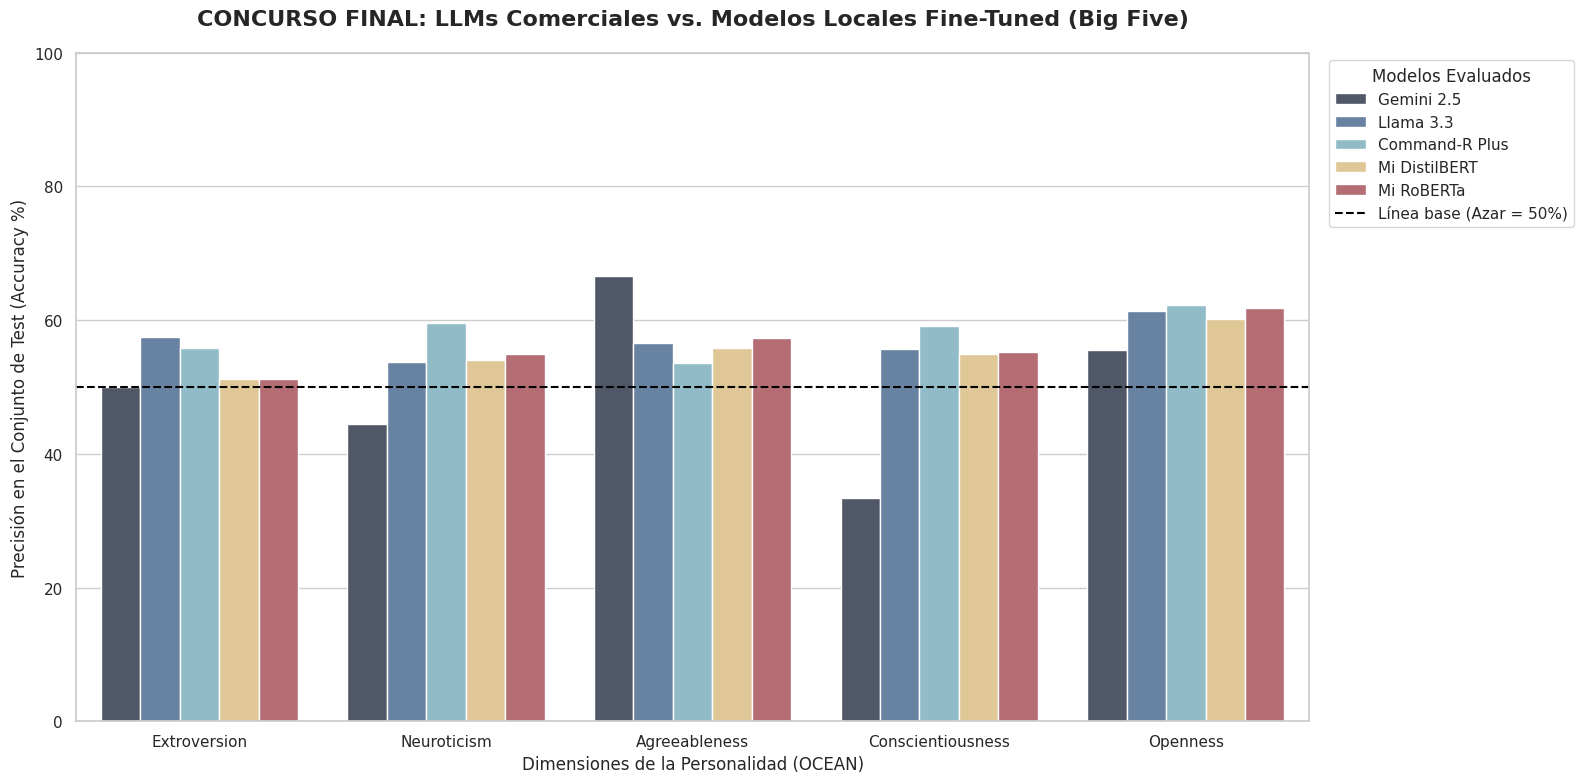

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ruta_carpeta = '/content/drive/MyDrive/TFM_Personalidad'

# 1. Reconstruimos los porcentajes limpios que sacaste paso a paso (sin textos, solo métricas)
datos_limpios = {
    'Modelo': ['Gemini 2.5']*5 + ['Llama 3.3']*5 + ['Command-R Plus']*5 + ['Mi DistilBERT']*5,
    'Rasgo': ['Extroversion', 'Neuroticism', 'Agreeableness', 'Conscientiousness', 'Openness'] * 4,
    'Accuracy (%)': [
        50.00, 44.44, 66.67, 33.33, 55.56,  # Gemini
        57.55, 53.77, 56.60, 55.66, 61.32,  # Llama 3.3
        55.80, 59.60, 53.60, 59.20, 62.20,  # Command-R Plus
        51.20, 54.00, 55.80, 55.00, 60.20   # DistilBERT
    ]
}
df_anterior_corregido = pd.DataFrame(datos_limpios)

# 2. Cargamos tu archivo de RoBERTa (que sí está perfecto, como se ve en tu captura)
df_roberta = pd.read_csv(f'{ruta_carpeta}/Resultados_RoBERTa.csv')

# 3. Los unimos limpiamente
df_tfm_absoluto = pd.concat([df_anterior_corregido, df_roberta], ignore_index=True)

# 4. CONFIGURAMOS EL GRÁFICO
plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")

paleta_colores = {
    'Gemini 2.5': '#4C566A',
    'Llama 3.3': '#5E81AC',
    'Command-R Plus': '#88C0D0',
    'Mi DistilBERT': '#EBCB8B',
    'Mi RoBERTa': '#BF616A'       # Tu mejor modelo en color destacado
}

grafico = sns.barplot(
    data=df_tfm_absoluto,
    x='Rasgo',
    y='Accuracy (%)',
    hue='Modelo',
    palette=paleta_colores
)

plt.title('CONCURSO FINAL: LLMs Comerciales vs. Modelos Locales Fine-Tuned (Big Five)', fontsize=16, pad=20, fontweight='bold')
plt.ylabel('Precisión en el Conjunto de Test (Accuracy %)', fontsize=12)
plt.xlabel('Dimensiones de la Personalidad (OCEAN)', fontsize=12)
plt.ylim(0, 100)

plt.axhline(50, color='black', linestyle='--', linewidth=1.5, label='Línea base (Azar = 50%)')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title="Modelos Evaluados")

plt.tight_layout()

# 5. Guardamos la imagen física y la mostramos
plt.savefig(f'{ruta_carpeta}/grafica_final_tfm.png', dpi=300, bbox_inches='tight')
print("¡Gráfica exportada correctamente como 'grafica_final_tfm.png' en tu Google Drive!")

plt.show()